In [1]:
from sklearn.metrics import mean_squared_error
import pandas as pd

# Load and pre-process data

In [2]:
target_col = "log_average_ms"

node_cols = ["Abs", "Acos", "Add", "ai.onnx.ml::CategoryMapper", "And", "ArgMax", 
             "AveragePool", "BatchNormalization", "Cast", "Ceil", "Clip", 
             "com.microsoft::BiasGelu", "com.microsoft::DynamicQuantizeLSTM", 
             "com.microsoft::DynamicQuantizeMatMul", "com.microsoft::FastGelu", 
             "com.microsoft::FusedConv", "com.microsoft::FusedGemm", 
             "com.microsoft::FusedMatMul", "com.microsoft::MatMulIntegerToFloat", 
             "com.microsoft::QGemm", "com.microsoft::QLinearAdd", 
             "com.microsoft::QLinearAveragePool", "com.microsoft::QLinearConcat", 
             "com.microsoft::QLinearGlobalAveragePool", "com.microsoft::QLinearLeakyRelu", 
             "com.microsoft::QLinearMul", "com.microsoft::QLinearSigmoid", 
             "com.microsoft::QuickGelu", "com.microsoft::SkipLayerNormalization", 
             "Compress", "Concat", "Constant", "ConstantOfShape", "Conv", "ConvInteger", 
             "ConvTranspose", "Cos", "CumSum", "DequantizeLinear", "Div", "Dropout", 
             "DynamicQuantizeLinear", "Einsum", "Equal", "Erf", "Exp", "Expand", 
             "EyeLike", "Flatten", "Floor", "Gather", "GatherElements", "GatherND", 
             "Gelu", "Gemm", "GlobalAveragePool", "Greater", "GreaterOrEqual", "Hardmax", 
             "HardSigmoid", "HardSwish", "Identity", "If", "InstanceNormalization", 
             "LayerNormalization", "LeakyRelu", "Less", "LessOrEqual", "local::preprocess", 
             "Log", "LogSoftmax", "Loop", "LRN", "LSTM", "MatMul", "MatMulInteger", 
             "Max", "MaxPool", "Min", "Mod", "Mul", "Neg", "NonMaxSuppression", "NonZero", 
             "Not", "OneHot", "Or", "Pad", "Pow", "PRelu", "QLinearConv", "QLinearMatMul", 
             "QuantizeLinear", "Range", "Reciprocal", "ReduceMax", "ReduceMean", "ReduceMin", 
             "ReduceProd", "ReduceSum", "Relu", "Reshape", "Resize", "RoiAlign", "Round", 
             "Scan", "ScatterElements", "ScatterND", "Shape", "Sigmoid", 
             "SimplifiedLayerNormalization", "Sin", "Slice", "Softmax", "Split", "Sqrt", 
             "Squeeze", "Sub", "Sum", "Tanh", "Tile", "TopK", "Transpose", "Trilu", 
             "Unsqueeze", "Where", "Xor"]


# node_cols = ["Constant", "Reshape", "Add", "Conv",
#              "Mul", "Transpose", "Relu", "MatMul",
#              "Gemm", "Unsqueeze"]


# extra_cols = ["movement_frac_x_cores", "mb_per_core"]

model_feature_cols = node_cols + ["conv_flops", "matmul_flops",
                "elementwise_mb", "reduction_mb", "normalization_mb",
                "movement_mb", "memory_mb"]

hardware_feature_cols = ["l1d_cache_kb", "l1i_cache_kb", "l2_cache_kb", 
                         "base_clock_mhz", "num_cores", "memory_bandwith_gbs", 
                         "cpu_provider"]

metadata_cols = ["model", "cpu_provider",
                 "machine_type", "platform", "run_id"]

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# load test, train, val sets

train_df = pd.read_csv("/content/drive/MyDrive/Data/train_set.csv")
val_df = pd.read_csv("/content/drive/MyDrive/Data/val_set.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Data/test_set.csv")

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (100252, 154)
val: (21483, 154)
test: (21483, 154)


In [5]:
assert list(train_df.columns) == list(val_df.columns) == list(test_df.columns)

train_df.head()

,model,input_dimensions,input_dtypes,output_dimensions,output_dtypes,conv_flops,matmul_flops,elementwise_mb,reduction_mb,normalization_mb,...,base_clock_mhz,memory_bandwith_gbs,cpu_provider,machine_type,platform,repo_file,average_ms,stddev_ms,min_ms,max_ms
0,hardcorenas_d_Opset17_extended.onnx,x:1x3x224x224,x:float32,668:1x1000,668:float32,472440512,2560000,50.528229,5.204269,0.000000,...,2300.000,717,intel,xeon_plat,bluehive,hardcorenas_d_Opset17.onnx,14.069188,0.082284,13.931521,14.247209
1,vit_base_patch8_224_in21k_Opset17_disable_all....,x:1x3x224x224,x:float32,1089:1x21843,1089:float32,231211008,156097479168,1771.169711,0.000000,792.141724,...,2450.000,205,amd,epyc,gcloud,vit_base_patch8_224_in21k_Opset17.onnx,1481.456045,150.199862,1094.324125,1632.506909
2,tf_efficientnetv2_m_in21ft1k_Opset17_basic.onnx,x:1x3x384x384,x:float32,2466:1x1000,2466:float32,31470991360,2560000,1201.339462,67.736023,0.000000,...,2449.998,205,amd,epyc,gcloud,tf_efficientnetv2_m_in21ft1k_Opset17.onnx,301.127424,12.889699,286.464729,324.336829
3,shufflenet_v2_x1_5_Opset16.onnx,x:1x3x224x224,x:float32,1137:1x1000,1137:float32,266034528,2048000,8.246674,1.630875,0.000000,...,2449.998,205,amd,epyc,gcloud,shufflenet_v2_x1_5_Opset16.onnx,8.161246,0.036559,8.080030,8.197800
4,wide_resnet101_2_Opset16_timm.onnx,x:1x3x224x224,x:float32,971:1x1000,971:float32,45502005248,4096000,252.656250,4.218750,0.000000,...,2300.000,717,intel,xeon_plat,bluehive,wide_resnet101_2_Opset16_timm.onnx,38.147223,0.068437,38.035275,38.292409


In [6]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler

In [ ]:
# pre-processing function

def preprocess(df: pd.DataFrame, train=False) -> pd.DataFrame:

  #drop rows with missing features
  df = df.dropna(subset=["average_ms"])

  #remove rows with high standard deviation (only for train)
  cv_limit = 0.1 # 10% cv limit
  df["cv"] = df["stddev_ms"] / df["average_ms"]

  # if train:
  df = df[df["cv"] <= cv_limit].copy()

  #add log_average_ms column
  df["log_average_ms"] = np.log(df["average_ms"])

  #remove decimals and round down
  for col in ["elementwise_mb", "reduction_mb", "normalization_mb", "movement_mb"]:
    df[col] = df[col].round(0)

  return df

In [8]:
train_df = preprocess(train_df, True)
test_df = preprocess(test_df, False)
val_df = preprocess(val_df, False)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (86784, 156)
val: (18626, 156)
test: (18618, 156)


In [9]:
for col in model_feature_cols:
    train_df[col] = np.log1p(train_df[col])
    val_df[col] = np.log1p(val_df[col])
    test_df[col] = np.log1p(test_df[col])

# Data Setup

In [10]:
target_col = "log_average_ms"

In [11]:
cpu_provider_map = {
    "intel": 0.0,
    "amd": 1.0,
}

for df in [train_df, val_df, test_df]:
    df["cpu_provider_binary"] = df["cpu_provider"].map(cpu_provider_map)

    if df["cpu_provider_binary"].isna().any():
        bad_values = df.loc[df["cpu_provider_binary"].isna(), "cpu_provider"].unique()
        raise ValueError(f"Unknown cpu_provider values: {bad_values}")

hardware_feature_cols.remove("cpu_provider")
hardware_feature_cols.append("cpu_provider_binary")

/tmp/ipykernel_18930/2739234318.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cpu_provider_binary"] = df["cpu_provider"].map(cpu_provider_map)
/tmp/ipykernel_18930/2739234318.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["cpu_provider_binary"] = df["cpu_provider"].map(cpu_provider_map)
/tmp/ipykernel_18930/2739234318.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using 

In [12]:
X_model_train = train_df[model_feature_cols].astype("float32").to_numpy()
X_model_val = val_df[model_feature_cols].astype("float32").to_numpy()
X_model_test = test_df[model_feature_cols].astype("float32").to_numpy()

X_hw_train = train_df[hardware_feature_cols].astype("float32").to_numpy()
X_hw_val = val_df[hardware_feature_cols].astype("float32").to_numpy()
X_hw_test = test_df[hardware_feature_cols].astype("float32").to_numpy()

y_train = train_df[target_col].astype("float32").to_numpy()
y_val = val_df[target_col].astype("float32").to_numpy()
y_test = test_df[target_col].astype("float32").to_numpy()

In [13]:
model_scaler = StandardScaler()
hw_scaler = StandardScaler()

X_model_train = model_scaler.fit_transform(X_model_train).astype("float32")
X_model_val = model_scaler.transform(X_model_val).astype("float32")
X_model_test = model_scaler.transform(X_model_test).astype("float32")

X_hw_train = hw_scaler.fit_transform(X_hw_train).astype("float32")
X_hw_val = hw_scaler.transform(X_hw_val).astype("float32")
X_hw_test = hw_scaler.transform(X_hw_test).astype("float32")

# Model Setup

In [14]:
def rmse_log(y_true, y_pred):
  return np.sqrt(mean_squared_error(y_true, y_pred))

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader

In [16]:
class TwoTowerLatencyDataset(Dataset):
    def __init__(self, X_model, X_hw, y):
        self.X_model = torch.from_numpy(X_model)
        self.X_hw = torch.from_numpy(X_hw)
        self.y = torch.from_numpy(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_model[idx], self.X_hw[idx], self.y[idx]

In [17]:
batch_size = 1024

train_loader = DataLoader(
    TwoTowerLatencyDataset(X_model_train, X_hw_train, y_train),
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    TwoTowerLatencyDataset(X_model_val, X_hw_val, y_val),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    TwoTowerLatencyDataset(X_model_test, X_hw_test, y_test),
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

In [18]:
import torch.nn as nn
import torch.nn.functional as F

In [19]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
        )
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        return self.norm(x + self.net(x))


class TwoTowerLatencyMLP(nn.Module):
    def __init__(self, n_model_features: int, n_hw_features: int):
        super().__init__()

        emb_dim = 128

        self.model_in = nn.Sequential(
            nn.Linear(n_model_features, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.10),
            nn.Linear(256, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.GELU(),
        )

        self.model_blocks = nn.Sequential(
            ResidualBlock(emb_dim, dropout=0.10),
            ResidualBlock(emb_dim, dropout=0.05),
        )

        self.hw_tower = nn.Sequential(
            nn.Linear(n_hw_features, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Linear(64, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.GELU(),
        )

        # Hardware produces feature-wise scale and shift for model embedding
        self.hw_film = nn.Linear(emb_dim, emb_dim * 2)

        self.fusion = nn.Sequential(
            nn.Linear(emb_dim * 4, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.10),

            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.05),

            nn.Linear(128, 1),
        )

    def forward(self, model_x, hw_x):
        model_emb = self.model_in(model_x)
        model_emb = self.model_blocks(model_emb)

        hw_emb = self.hw_tower(hw_x)

        gamma, beta = self.hw_film(hw_emb).chunk(2, dim=1)
        conditioned_model = model_emb * (1 + gamma) + beta

        interaction = conditioned_model * hw_emb
        diff = torch.abs(conditioned_model - hw_emb)

        fused = torch.cat(
            [conditioned_model, hw_emb, interaction, diff],
            dim=1,
        )

        return self.fusion(fused).squeeze(1)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [21]:
print("model features:", X_model_train.shape[1])
print("hardware features:", X_hw_train.shape[1])

model features: 134
hardware features: 7


In [22]:
model = TwoTowerLatencyMLP(
    n_model_features=len(model_feature_cols),
    n_hw_features=X_hw_train.shape[1],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

loss_fn = nn.SmoothL1Loss()  # Huber loss on log latency

# Model Training

In [23]:
from sklearn.metrics import mean_squared_error

In [24]:
def evaluate_mlp(model, loader):
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for model_x, hw_x, y in loader:
            model_x = model_x.to(device)
            hw_x = hw_x.to(device)
            y = y.to(device)

            pred = model(model_x, hw_x)

            preds.append(pred.cpu().numpy())
            targets.append(y.cpu().numpy())

    y_pred = np.concatenate(preds)
    y_true = np.concatenate(targets)

    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))

    true_ms = np.exp(y_true)
    pred_ms = np.exp(y_pred)

    rel_err = np.abs(pred_ms - true_ms) / true_ms

    metrics = {
        "rmse_log": rmse_log,
        "rmse_ms": np.sqrt(mean_squared_error(true_ms, pred_ms)),
        "rmse_percent": np.sqrt(mean_squared_error(rel_err, np.zeros_like(rel_err))),
        "median_relative_error": np.median(rel_err),
        "p90_relative_error": np.percentile(rel_err, 90),
        "p95_relative_error": np.percentile(rel_err, 95),
        "within_10pct": np.mean(rel_err <= 0.10),
        "median_ratio_error": np.median(np.maximum(pred_ms / true_ms, true_ms / pred_ms)),
        "p90_ratio_error": np.percentile(np.maximum(pred_ms / true_ms, true_ms / pred_ms), 90),
        "within_25pct": np.mean(rel_err <= 0.25),
        "within_50pct": np.mean(rel_err <= 0.50),
        "within_2x": np.mean(np.maximum(pred_ms / true_ms, true_ms / pred_ms) <= 2.0),
    }

    return metrics, y_true, y_pred

In [29]:
# best_val_rmse = float("inf")
# best_state = None

num_epochs = 1000

# history = []

for epoch in range(501, num_epochs + 1):
    model.train()
    train_losses = []

    for model_x, hw_x, y in train_loader:
        model_x = model_x.to(device)
        hw_x = hw_x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(model_x, hw_x)
        loss = loss_fn(pred, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

    val_metrics, _, _ = evaluate_mlp(model, val_loader)
    val_rmse = val_metrics["rmse_log"]

    history.append({
        "epoch": epoch,
        "train_loss": np.mean(train_losses),
        **val_metrics,
    })

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_state = {
            "model": model.state_dict(),
            "epoch": epoch,
            "val_rmse": val_rmse,
        }

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"epoch {epoch:03d} | "
            f"train_loss={np.mean(train_losses):.5f} | "
            f"val_rmse_log={val_rmse:.5f} | "
            f"within_10={val_metrics['within_10pct']:.4f} | "
            f"best={best_val_rmse:.5f}"
        )

epoch 505 | train_loss=0.01876 | val_rmse_log=0.20254 | within_10=0.7736 | best=0.19919
epoch 510 | train_loss=0.01882 | val_rmse_log=0.20416 | within_10=0.7539 | best=0.19919
epoch 515 | train_loss=0.01773 | val_rmse_log=0.19995 | within_10=0.8002 | best=0.19897
epoch 520 | train_loss=0.01761 | val_rmse_log=0.20064 | within_10=0.7903 | best=0.19897
epoch 525 | train_loss=0.01774 | val_rmse_log=0.20103 | within_10=0.8013 | best=0.19897
epoch 530 | train_loss=0.01818 | val_rmse_log=0.20324 | within_10=0.7852 | best=0.19897
epoch 535 | train_loss=0.01843 | val_rmse_log=0.20097 | within_10=0.7953 | best=0.19897
epoch 540 | train_loss=0.01752 | val_rmse_log=0.20089 | within_10=0.7927 | best=0.19897
epoch 545 | train_loss=0.01896 | val_rmse_log=0.20098 | within_10=0.7907 | best=0.19897
epoch 550 | train_loss=0.01798 | val_rmse_log=0.21171 | within_10=0.7321 | best=0.19897
epoch 555 | train_loss=0.01762 | val_rmse_log=0.20108 | within_10=0.7924 | best=0.19897
epoch 560 | train_loss=0.01740 |

# Evaluation

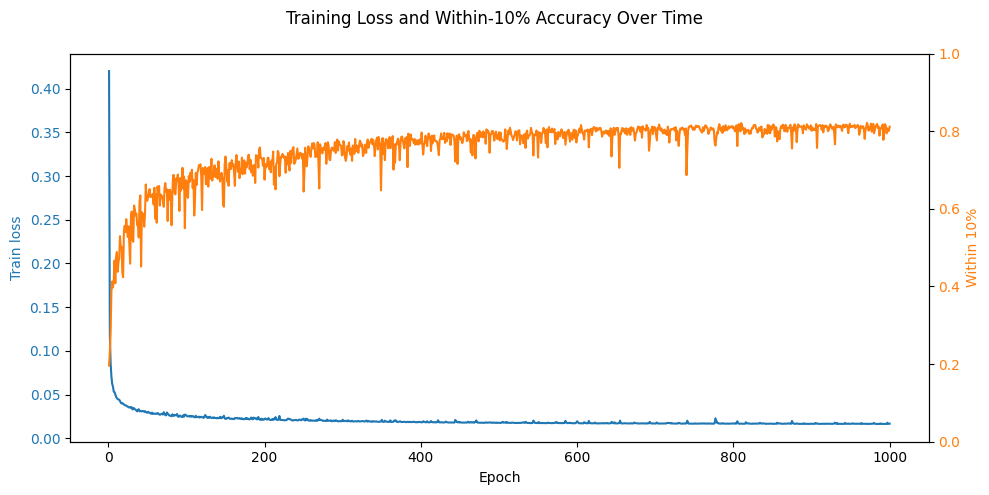

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train loss",
    color="tab:blue",
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()

ax2.plot(
    history_df["epoch"],
    history_df["within_10pct"],
    label="Within 10%",
    color="tab:orange",
)

ax2.set_ylabel("Within 10%", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
ax2.set_ylim(0, 1)

fig.suptitle("Training Loss and Within-10% Accuracy Over Time")
fig.tight_layout()
plt.show()


In [31]:
model.load_state_dict(best_state["model"])
print("Best epoch:", best_state["epoch"])
print("Best val RMSE:", best_state["val_rmse"])

Best epoch: 514
Best val RMSE: 0.19897184779585225


In [32]:
val_metrics, val_true_log, val_pred_log = evaluate_mlp(model, val_loader)
test_metrics, test_true_log, test_pred_log = evaluate_mlp(model, test_loader)

pd.DataFrame([val_metrics, test_metrics], index=["val", "test"])

,rmse_log,rmse_ms,rmse_percent,median_relative_error,p90_relative_error,p95_relative_error,within_10pct,median_ratio_error,p90_ratio_error,within_25pct,within_50pct,within_2x
val,0.201146,159.780984,0.330089,0.033915,0.186311,0.332370,0.811554,1.034221,1.207050,0.928917,0.973532,0.986309
test,0.184074,137.115314,0.241757,0.033063,0.183139,0.335882,0.817381,1.033411,1.203155,0.930229,0.974756,0.987109


# Save Model

In [81]:
from pathlib import Path
import torch

model_dir = Path("/content/drive/MyDrive/Models")
model_dir.mkdir(parents=True, exist_ok=True)

save_path = model_dir / "6.pt"

# If using early stopping, load best weights before saving
if "best_state" in globals() and best_state is not None:
    model.load_state_dict(best_state["model"])

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "n_model_features": X_model_train.shape[1],
        "n_hw_features": X_hw_train.shape[1],
        "model_feature_cols": model_feature_cols,
        "model_scaler": model_scaler,
        "hw_scaler": hw_scaler,
        "target_col": "log_average_ms",
        "best_val_rmse": best_val_rmse if "best_val_rmse" in globals() else None,
    },
    save_path,
)

print("Saved to:", save_path)

Saved to: /content/drive/MyDrive/Models/6.pt


# Analysis

In [45]:
test_results = test_df.copy()

test_results["pred_log_latency"] = test_pred_log
test_results["true_log_latency"] = test_true_log

test_results["pred_latency_ms"] = np.exp(test_results["pred_log_latency"])
test_results["true_latency_ms"] = np.exp(test_results["true_log_latency"])

test_results["relative_error"] = (
    np.abs(test_results["pred_latency_ms"] - test_results["true_latency_ms"])
    / test_results["true_latency_ms"]
)

In [46]:
def group_latency_metrics(g):
    y_true = g["true_log_latency"].to_numpy()
    y_pred = g["pred_log_latency"].to_numpy()

    true_ms = np.exp(y_true)
    pred_ms = np.exp(y_pred)

    rel_err = np.abs(pred_ms - true_ms) / true_ms

    return pd.Series({
        "count": len(g),
        "rmse_log": np.sqrt(mean_squared_error(y_true, y_pred)),
        "within_10pct": np.mean(rel_err <= 0.10),
        "within_25pct": np.mean(rel_err <= 0.25),
        "within_50pct": np.mean(rel_err <= 0.50),
    })

In [47]:
test_results["abs_log_error"] = np.abs(
    test_results["pred_log_latency"] - test_results["true_log_latency"]
)

test_results.groupby(["cpu_provider", "platform", "num_cores"])["relative_error"].agg(
    count="count",
    median="median",
    p90=lambda x: x.quantile(0.9),
    within_10pct=lambda x: (x <= 0.10).mean(),
    within_25pct=lambda x: (x <= 0.25).mean(),
).reset_index()

,cpu_provider,platform,num_cores,count,median,p90,within_10pct,within_25pct
0,amd,gcloud,1,2636,0.023210,0.092936,0.908574,0.979514
1,amd,gcloud,2,4015,0.044060,0.177614,0.767123,0.953176
2,amd,gcloud,4,2737,0.052551,0.254220,0.700767,0.896237
3,intel,bluehive,1,1347,0.022236,0.166909,0.851522,0.948775
4,intel,bluehive,2,2686,0.018175,0.154792,0.854803,0.934475
5,intel,bluehive,4,3999,0.021426,0.257947,0.802201,0.898225
6,intel,bluehive,8,2712,0.034885,0.478296,0.708333,0.807891
7,intel,gcloud,6,1351,0.025511,0.209834,0.823094,0.916358


In [50]:
test_results.groupby(["cpu_provider", "platform", "num_cores"])["cv"].agg(
    within_10pct=lambda x: (x <= 0.10).mean(),
    count="count",
    median="median",
    p90=lambda x: x.quantile(0.9),
).reset_index()

,cpu_provider,platform,num_cores,within_10pct,count,median,p90
0,amd,gcloud,1,0.994310,2636,0.008788,0.027356
1,amd,gcloud,2,0.937235,4015,0.031481,0.086614
2,amd,gcloud,4,0.910851,2737,0.038253,0.096363
3,intel,bluehive,1,1.000000,1347,0.002264,0.006687
4,intel,bluehive,2,1.000000,2686,0.004681,0.017785
5,intel,bluehive,4,0.980495,3999,0.004934,0.020884
6,intel,bluehive,8,0.865413,2712,0.004852,0.207891
7,intel,gcloud,6,0.999260,1351,0.007213,0.016820


In [51]:
test_results.groupby(["cpu_provider", "platform", "num_cores"]).apply(
    group_latency_metrics,
    include_groups=False
).reset_index()

,cpu_provider,platform,num_cores,count,rmse_log,within_10pct,within_25pct,within_50pct
0,amd,gcloud,1,2636.0,0.087102,0.908574,0.979514,0.995068
1,amd,gcloud,2,4015.0,0.142931,0.767123,0.953176,0.987049
2,amd,gcloud,4,2737.0,0.173881,0.700767,0.896237,0.977713
3,intel,bluehive,1,1347.0,0.201887,0.851522,0.948775,0.972532
4,intel,bluehive,2,2686.0,0.196294,0.854803,0.934475,0.970588
5,intel,bluehive,4,3999.0,0.227768,0.802201,0.898225,0.958490
6,intel,bluehive,8,2712.0,0.354221,0.708333,0.807891,0.904867
7,intel,gcloud,6,1351.0,0.206487,0.823094,0.916358,0.964471
